In [2]:
import re
import os
import io
from glob import glob
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
style_path = os.path.join(os.path.dirname(scienceplots.__file__), 'styles')
plt.style.core.USER_LIBRARY_PATHS.append(style_path)
plt.style.reload_library()
plt.style.use("science")
mpl.rcParams["text.usetex"] = False
from matplotlib import ticker
import tol_colors as tc
cset = tc.colorsets["medium_contrast"]

In [3]:
LOG_DIR = "./result/logs/"
OUT_DIR = "./img/gaps"

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
METHOD_NAME_MAP = {
    "RC": "cls100",
    "LT": "thd100",
    "EX": "ex",
}

## Load Data

In [80]:
def loadTables(method="RC", size=5):
    """
    Load tables from the log file
    """
    if method not in METHOD_NAME_MAP:
        raise ValueError(f"Unknown method '{method}', expected one of: {list(METHOD_NAME_MAP.keys())}")

    method_tag = METHOD_NAME_MAP[method]
    size_str = f"{size}-{size}"

    pattern = os.path.join(LOG_DIR, f"cq_{method_tag}_{size_str}_*.log")
    log_paths = sorted(glob(pattern))

    if len(log_paths) == 0:
        raise FileNotFoundError(f"No log files match pattern {pattern}")

    all_tables = []
    for path in log_paths:
        with open(path, "r") as f:
            log_content = f.read()
        table = extractRawTable(log_content)
        table["instance"] = int(path.split(".")[1].split("_")[-1])
        all_tables.append(table)

    return all_tables

def extractRawTable(log_content):
    """
    Extract table sections from the log file content.
    """
    
    header_pattern = r"""
        Nodes\s+\|\s+Current\s+Node\s+\|\s+Objective\s+Bounds\s+\|\s+Work\s+
        Expl\s+Unexpl\s+\|\s+Obj\s+Depth\s+IntInf\s+\|\s+Incumbent\s+BestBd\s+Gap\s+\|\s+It/Node\s+Time
    """
    end_pattern = r"Explored"
    
    start_pattern = re.compile(header_pattern.strip(), re.VERBOSE | re.MULTILINE)
    end_pattern = re.compile(end_pattern.strip(), re.VERBOSE | re.MULTILINE)
    
    start_matches = list(start_pattern.finditer(log_content))
    end_matches = list(end_pattern.finditer(log_content))
    
    start = start_matches[0].end()
    end = end_matches[0].start()
    table_content = log_content[start:end].strip()
    table = getCleanTable(table_content)

    t_opt, v_opt = getOptimal(log_content)
    if t_opt is not None and not table.empty:
        extra = pd.DataFrame({col: [np.nan] for col in table.columns})
        extra["Time"] = t_opt
        extra["Gap"]  = 0.0
        extra["BestBd"] = v_opt
        table = pd.concat([table, extra], ignore_index=True)
        
    return table

def getCleanTable(table_content):
    """
    Convert a Gurobi node log table into a pandas DataFrame.
    """
    rows = []
    
    for line in table_content.splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith("H"):
            line = line[1:].lstrip()
            
        parts = line.split()
        incumbent, bestbd, gap, _, time = parts[-5:]
        rows.append({"Incumbent": incumbent, "BestBd": bestbd, "Gap": gap, "Time": time})   

    df = pd.DataFrame(rows)

    df["Incumbent"] = df["Incumbent"].astype(str).str.replace("s", "", regex=False).replace({"-": None, "None": None, "nan": None}).astype(float)
    df["BestBd"] = df["BestBd"].astype(str).str.replace("s", "", regex=False).replace({"-": None, "None": None, "nan": None}).astype(float)
    df["Gap"]  = df["Gap"].astype(str).str.replace("%", "", regex=False).replace({"-": None, "None": None, "nan": None}).astype(float) / 100
    df["Time"] = df["Time"].astype(str).str.replace("s", "", regex=False).replace({"-": None, "None": None, "nan": None}).astype(float)

    return df

def getOptimal(log_content):
    """
    Get the total time if the optimal solution is found
    """
    if "Optimal solution found" not in log_content:
        return None, None
    else:
        m =  re.search(r"Explored .* in ([0-9.]+) seconds", log_content)
        t_opt = float(m.group(1)) if m else None
        
    m = re.search(r"Optimal objective\s+([-+]?[0-9]*\.?[0-9]+)", log_content)
    if m:
        opt_val = float(m.group(1))
        return t_opt, opt_val

    m = re.search(r"Best objective\s+([-+]?[0-9]*\.?[0-9]+)", log_content)
    if m:
        opt_val = float(m.group(1))
        return t_opt, opt_val

    return t_opt, None

In [82]:
# test
tables = loadTables(method="RC", size=100)

## Best Bound

In [85]:
def computeBestBounds(all_method_tables):
    """
    """
    instance_best_bound = [-np.inf] * 10

    for tables in all_method_tables:
        for table in tables:
            i = int(table["instance"].iloc[0])
            v = table["BestBd"].max()
            instance_best_bound[i] = max(instance_best_bound[i], v)
    return instance_best_bound

In [87]:
table_rc = loadTables(method="RC", size=20)
table_lt = loadTables(method="LT", size=20)
table_ex = loadTables(method="EX", size=20)
instance_best_bound = computeBestBounds([table_rc, table_lt, table_ex])
print(instance_best_bound)

[-5.462054966068, -5.126614793033, -5.48483002083, -4.656760373378, -5.152735616598, -5.50582231062, -5.375962910955, -4.888049549786, -5.134783524442, -4.524751349083]


## Load Data

In [90]:
def aggregateTables(tables):
    """
    Given a list of tables, parse and process them into a unified
    time-aligned DataFrame with gap percentiles (q25, q50, q75).
    """
    processed_dfs = []
    for idx, table in enumerate(tables):
        if table.empty:
            print(f"Table {idx} skipped (no data)")
            continue
        processed_dfs.append(processTime(table))
    combined_df = pd.concat(processed_dfs, ignore_index=True)
    
    aggregated = combined_df.groupby("Time")["Gap"].agg(
        q25=lambda x: np.percentile(x, 25),
        q50=lambda x: np.percentile(x, 50),
        q75=lambda x: np.percentile(x, 75)
    ).reset_index()
    
    return aggregated

def processTime(raw_df):
    """
    Process time-gap data: interpolation and align to the full time range.
    """
    raw_df = raw_df.groupby("Time", as_index=False)["Gap"].min().sort_values("Time")

    full_time = np.arange(0, 10801)
    interp_gap = interp1d(raw_df["Time"], raw_df["Gap"], kind="previous", fill_value="extrapolate")(full_time)
    
    return pd.DataFrame({"Time": full_time, "Gap": interp_gap})

In [92]:
df = aggregateTables(tables)
df.head()

,Time,q25,q50,q75
0,0,0.14575,0.1685,0.18425
1,1,0.13925,0.1525,0.17150
2,2,0.12325,0.1335,0.15875
3,3,0.12050,0.1245,0.13800
4,4,0.12025,0.1215,0.13600


## Plot

In [94]:
def plotGapLogs(size):
    """
    Plot optimality gap curves from multiple Gurobi.log files.
    """
    # init
    methods = ["RC", "LT", "EX"]
    colors = {
        "EX": cset.light_yellow,
        "RC": cset.dark_blue,
        "LT": cset.dark_red,
    }
    labels = {
        "EX": "No Warm-Starting",
        "RC": "Start from RC-P",
        "LT": "Start from LT-P",
    }

    # get tables
    all_method_tables = []
    method_to_tables = {}
    for method in methods:
        print(f"[Info] Loading logs for method={method}, size={size}")
        try:
            tables = loadTables(method, size)   # list[DataFrame]
        except Exception as e:
            print(f"[Error] Failed to load tables for {method}: {e}")
            continue
        all_method_tables.append(tables)
        method_to_tables[method] = tables
    if not method_to_tables:
        print("[Error] No tables loaded for any method.")
        return

    # best bound
    instance_best_bound = computeBestBounds(all_method_tables)
    print("[Info] Per-instance best bounds:")
    for i, bnd in enumerate(instance_best_bound):
        print(f"  Instance {i}: {bnd}")

    # redefine gap
    for method, tables in method_to_tables.items():
        for table in tables:
            inst = int(table["instance"].iloc[0])
            lb = instance_best_bound[inst]
            table["Gap"] = (table["Incumbent"] - lb) / (abs(lb) + 1e-10)
    
    plt.figure(figsize=(10, 6))    
    # go through methods
    for method in methods:
        tables = method_to_tables[method]
        # get aggregated statistics
        aggregated = aggregateTables(tables)
        if aggregated.empty:
            print(f"[Warning] No valid data for method {method}")
            continue
        aggregated = truncateOnConvergence(aggregated)

        # color and label
        color = colors[method]
        label = labels[method]

        # interquartile shading
        plt.fill_between(aggregated["Time"], aggregated["q25"] * 100, aggregated["q75"] * 100, color=color, alpha=0.3)
        # median curve
        plt.plot(aggregated["Time"], aggregated["q50"] * 100, label=label, color=color, lw=4)

    # figure settings
    plt.title(f"{size}×{size} IQP", fontsize=36)
    plt.xlabel("Time (seconds)", fontsize=32)
    plt.ylabel("Best-Bound Gap", fontsize=32)
    plt.grid(True, linestyle=":")
    plt.legend(fontsize=24)
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    plt.tick_params(labelsize=24)
    plt.tight_layout()

    # save
    outfile = os.path.join(OUT_DIR, f"gap_cq_{size}x{size}.pdf")
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"[Success] Plot saved as {outfile}")

def truncateOnConvergence(aggregated, tol=1e-6):
    """
    Cut the aggregated table when q75 first becomes zero (within tol).
    """
    arr = aggregated["q75"].values
    idx = np.where(arr <= tol)[0]
    if len(idx) == 0:
        return aggregated  # never converged → return whole
    cut = idx[0]  # first index where gap hits zero
    return aggregated.iloc[: cut+1]

[Info] Loading logs for method=RC, size=20
[Info] Loading logs for method=LT, size=20
[Info] Loading logs for method=EX, size=20
[Info] Per-instance best bounds:
  Instance 0: -5.462054966068
  Instance 1: -5.126614793033
  Instance 2: -5.48483002083
  Instance 3: -4.656760373378
  Instance 4: -5.152735616598
  Instance 5: -5.50582231062
  Instance 6: -5.375962910955
  Instance 7: -4.888049549786
  Instance 8: -5.134783524442
  Instance 9: -4.524751349083
[Success] Plot saved as ./img/gaps\gap_cq_20x20.pdf


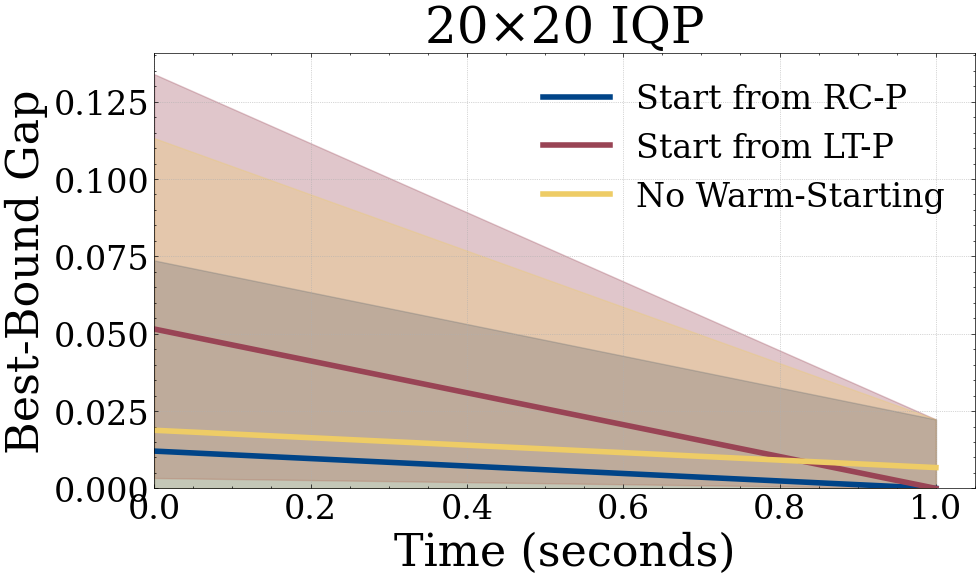

In [95]:
plotGapLogs(size=20)

In [101]:
plotGapLogs(size=50)

[Info] Loading logs for method=RC, size=50
[Error] Failed to load tables for RC: No log files match pattern ./result/logs/cq_cls100_50-50_*.log
[Info] Loading logs for method=LT, size=50
[Error] Failed to load tables for LT: No log files match pattern ./result/logs/cq_thd100_50-50_*.log
[Info] Loading logs for method=EX, size=50
[Error] Failed to load tables for EX: No log files match pattern ./result/logs/cq_ex_50-50_*.log
[Error] No tables loaded for any method.


[Info] Loading logs for method=RC, size=100
[Info] Loading logs for method=LT, size=100
[Info] Loading logs for method=EX, size=100
[Error] Failed to load tables for EX: No log files match pattern ./result/logs/cq_ex_100-100_*.log
[Info] Per-instance best bounds:
  Instance 0: -22.27686
  Instance 1: -22.17292
  Instance 2: -21.72935
  Instance 3: -21.35524
  Instance 4: -22.64844
  Instance 5: -21.6936
  Instance 6: -21.76896
  Instance 7: -21.22886
  Instance 8: -22.14096
  Instance 9: -21.68949


KeyError: 'EX'

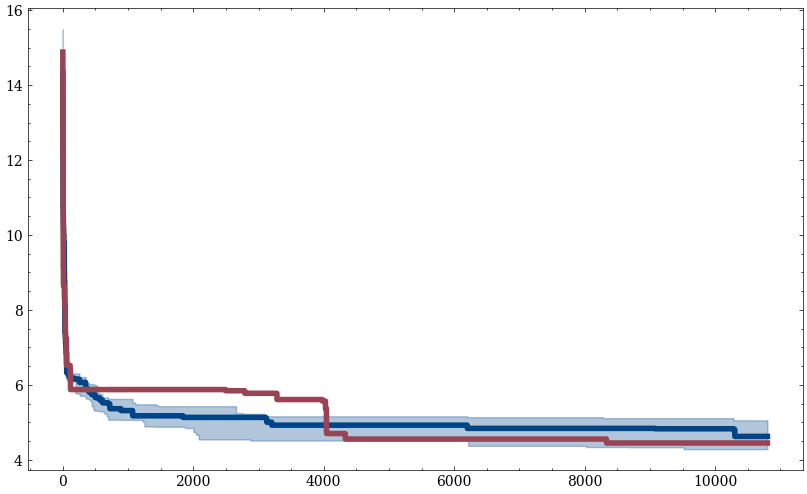

In [103]:
plotGapLogs(size=100)

[Info] Loading logs for method=RC, size=200
[Info] Loading logs for method=LT, size=200
[Info] Loading logs for method=EX, size=200
[Info] Per-instance best bounds:
  Instance 0: -46.39217
  Instance 1: -46.44943
  Instance 2: -47.11997
  Instance 3: -46.21176
  Instance 4: -46.97228
  Instance 5: -46.61138
  Instance 6: -47.30228
  Instance 7: -46.55796
  Instance 8: -47.41232
  Instance 9: -47.21759
[Success] Plot saved as ./img/gaps\gap_cq_200x200.pdf


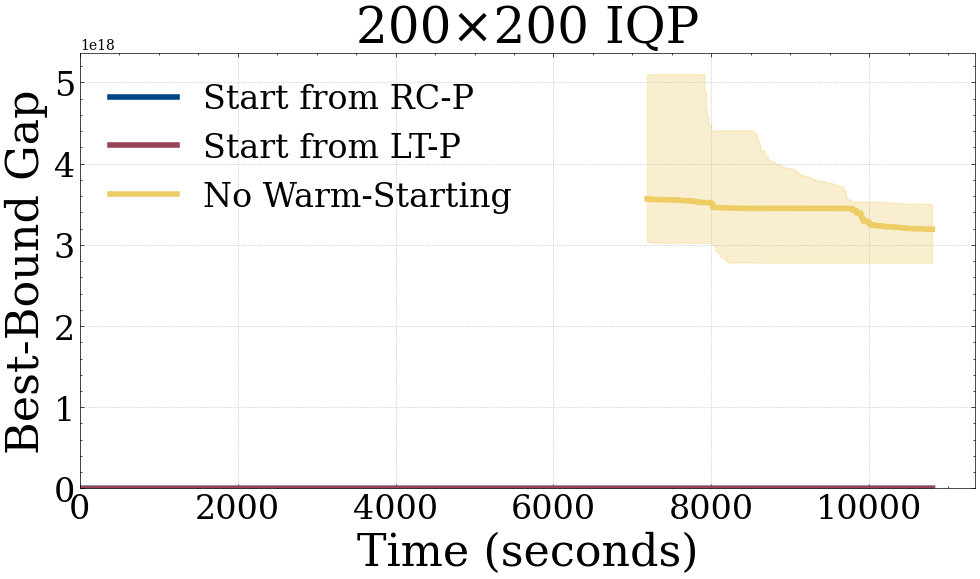

In [105]:
plotGapLogs(size=200)

[Info] Loading logs for method=RC, size=500
[Info] Loading logs for method=LT, size=500
[Info] Loading logs for method=EX, size=500
[Info] Per-instance best bounds:
  Instance 0: -106.381
  Instance 1: -106.7949
  Instance 2: -106.16081
  Instance 3: -106.78612
  Instance 4: -106.43742
  Instance 5: -106.72228
  Instance 6: -106.79557
  Instance 7: -106.76547
  Instance 8: -106.21471
  Instance 9: -106.81842
[Success] Plot saved as ./img/gaps\gap_cq_500x500.pdf


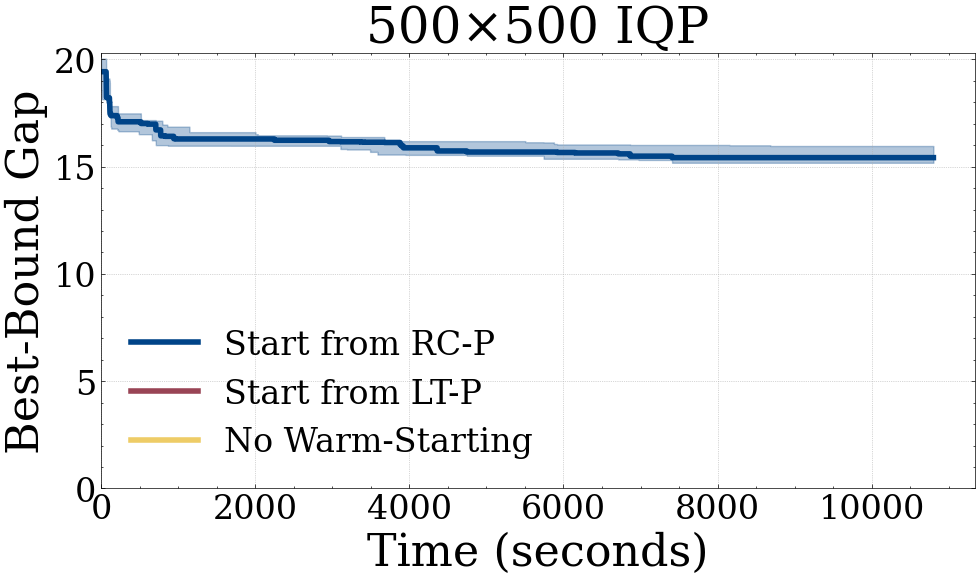

In [106]:
plotGapLogs(size=500)